# Notebook 2: Dimensionality Reduction
## Hyperspectral Data Science for Corn

**Objectives:**
- Load preprocessed train/test data
- Apply PCA (Principal Component Analysis)
- Visualize explained variance
- Create 2D and 3D PCA visualizations
- Analyze feature contributions
- Apply t-SNE for cluster visualization
- Save reduced datasets

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Preprocessed Data

In [2]:
# Load scaled train and test data
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded successfully!
X_train shape: (400, 448)
X_test shape: (100, 448)
y_train shape: (400,)
y_test shape: (100,)


## 2. Principal Component Analysis (PCA)

In [3]:
# Apply PCA with all components
pca_full = PCA()
pca_full.fit(X_train)

print(f"Original features: {X_train.shape[1]}")
print(f"PCA components: {pca_full.n_components_}")

Original features: 448
PCA components: 400


## 3. Explained Variance Analysis

In [4]:
# Cumulative explained variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% and 99% variance
n_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_99 = np.argmax(cumsum_variance >= 0.99) + 1

print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")
print(f"Variance explained by first 10 components: {cumsum_variance[9]:.4f}")

Components for 95% variance: 3
Components for 99% variance: 125
Variance explained by first 10 components: 0.9669


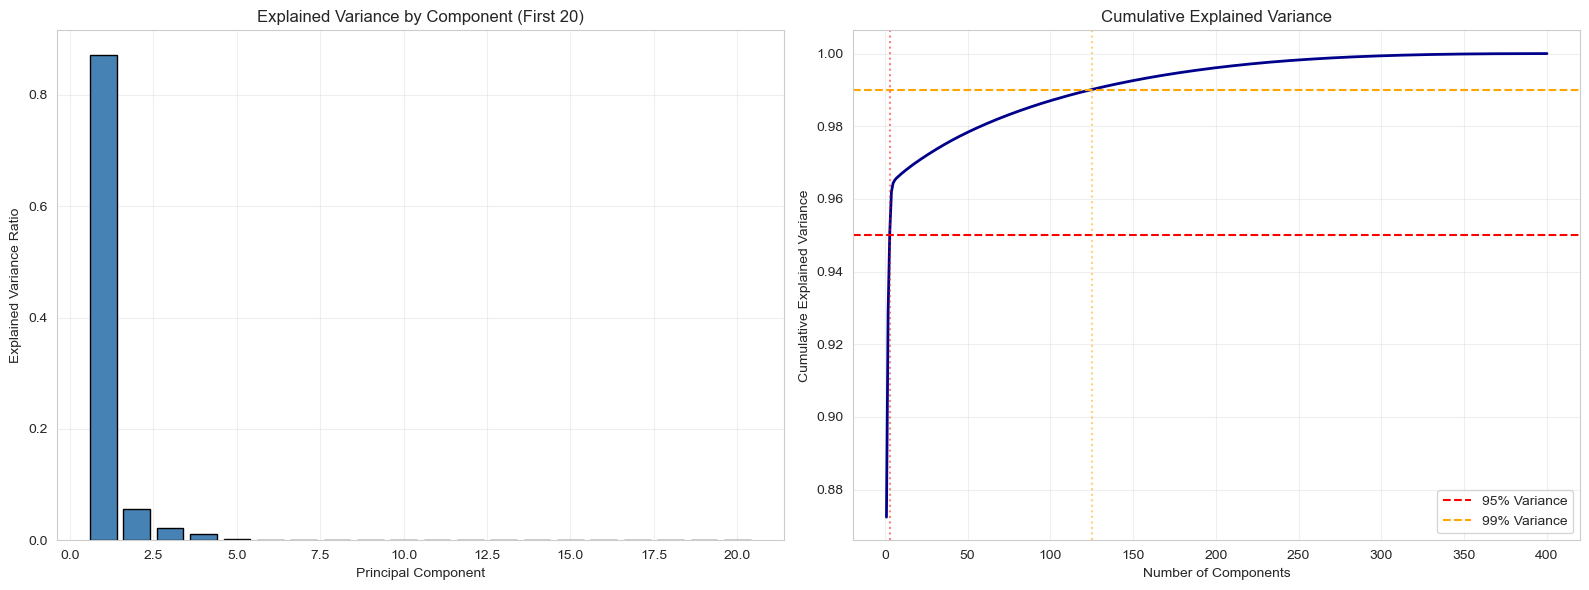

In [5]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual variance
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance by Component (First 20)')
axes[0].grid(alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumsum_variance) + 1), cumsum_variance, linewidth=2, color='darkblue')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
axes[1].axhline(y=0.99, color='orange', linestyle='--', label='99% Variance')
axes[1].axvline(x=n_95, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_99, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/pca_explained_variance.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Apply PCA with Optimal Components

In [6]:
# Use components that explain 95% variance
pca = PCA(n_components=n_95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Reduced training shape: {X_train_pca.shape}")
print(f"Reduced test shape: {X_test_pca.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")

Reduced training shape: (400, 3)
Reduced test shape: (100, 3)
Variance retained: 0.9508


## 5. 2D PCA Visualization

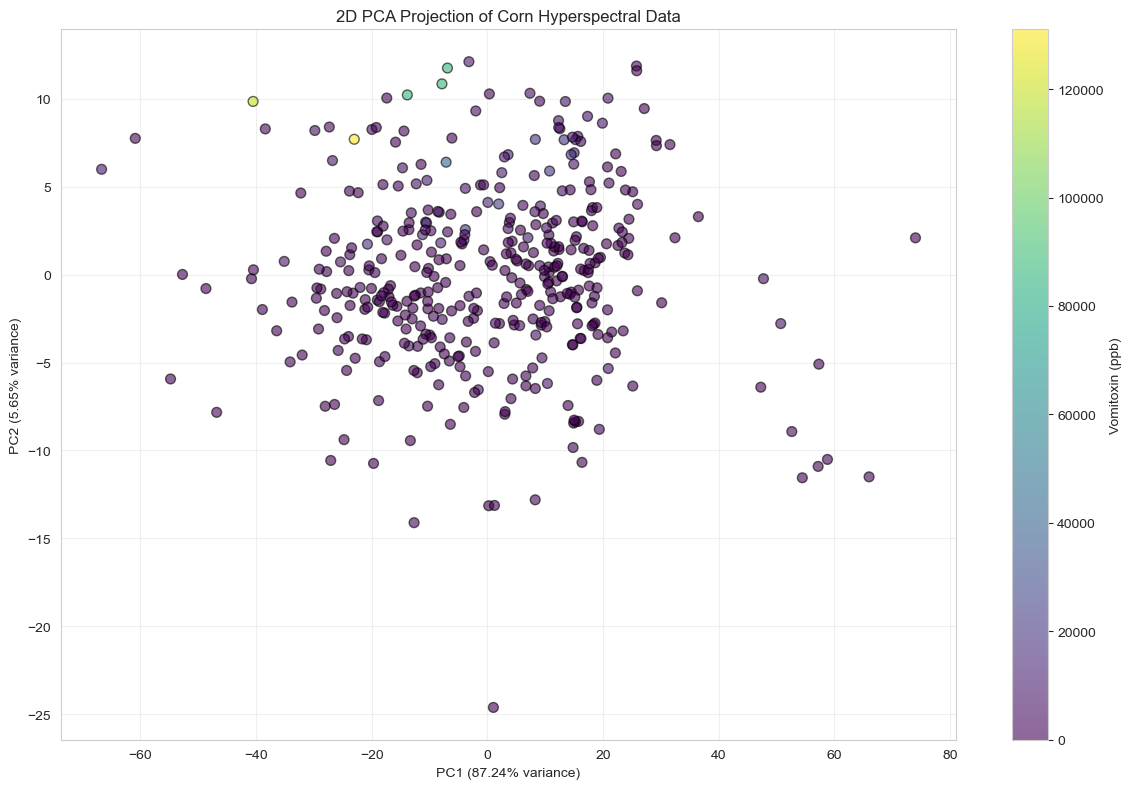

In [7]:
# 2D scatter plot colored by target
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                     c=y_train, cmap='viridis', alpha=0.6, edgecolors='black', s=50)
plt.colorbar(scatter, label='Vomitoxin (ppb)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('2D PCA Projection of Corn Hyperspectral Data')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/pca_2d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. 3D PCA Visualization

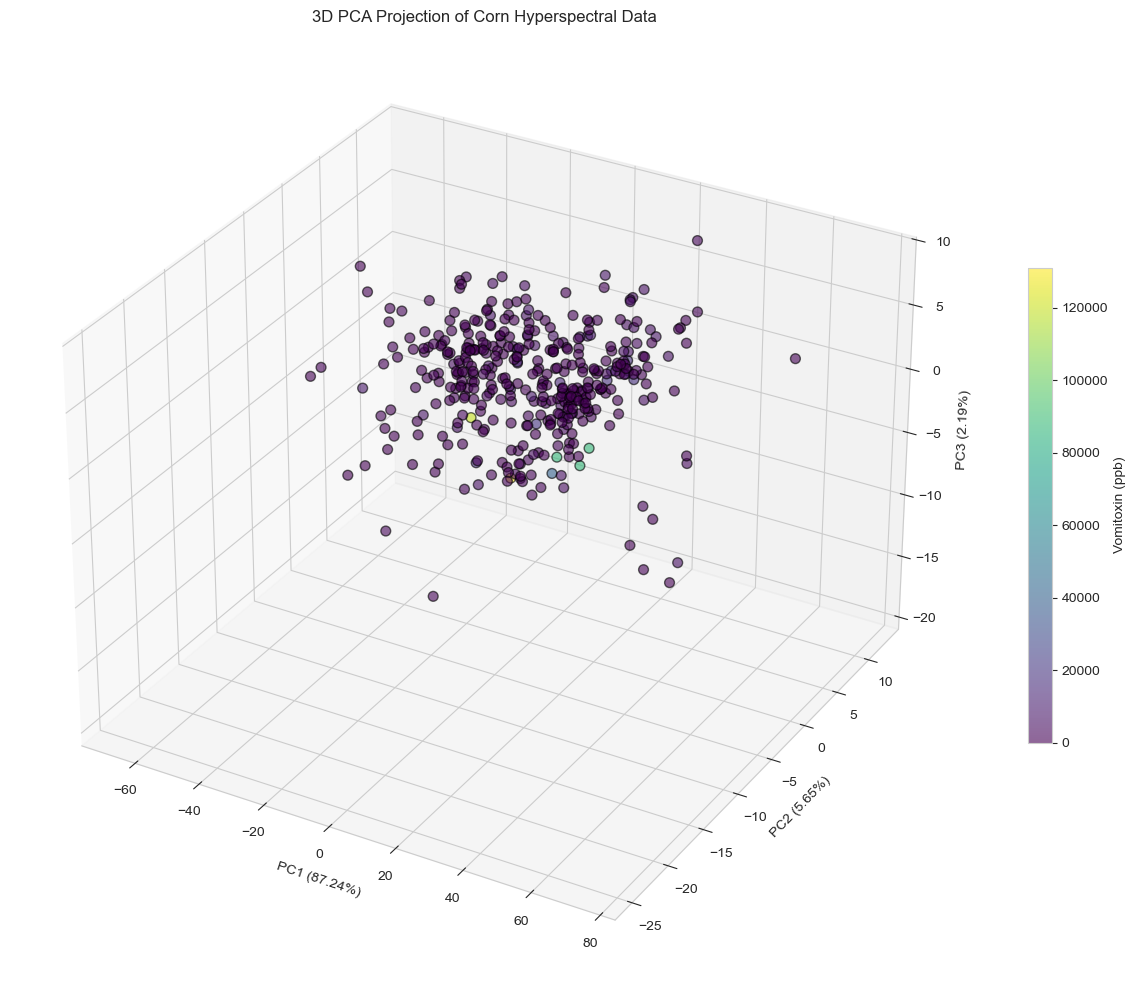

In [8]:
# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2],
                    c=y_train, cmap='viridis', alpha=0.6, edgecolors='black', s=50)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})')
ax.set_title('3D PCA Projection of Corn Hyperspectral Data')

plt.colorbar(scatter, label='Vomitoxin (ppb)', shrink=0.5)
plt.tight_layout()
plt.savefig('../outputs/pca_3d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Feature Contribution Analysis

In [9]:
# Top contributing features for first 3 PCs
components_df = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_train.columns
)

print("Top 10 features contributing to PC1:")
print(components_df['PC1'].abs().sort_values(ascending=False).head(10))

Top 10 features contributing to PC1:
295    0.049594
271    0.049578
278    0.049563
247    0.049538
269    0.049533
294    0.049523
314    0.049522
309    0.049522
302    0.049520
308    0.049496
Name: PC1, dtype: float64


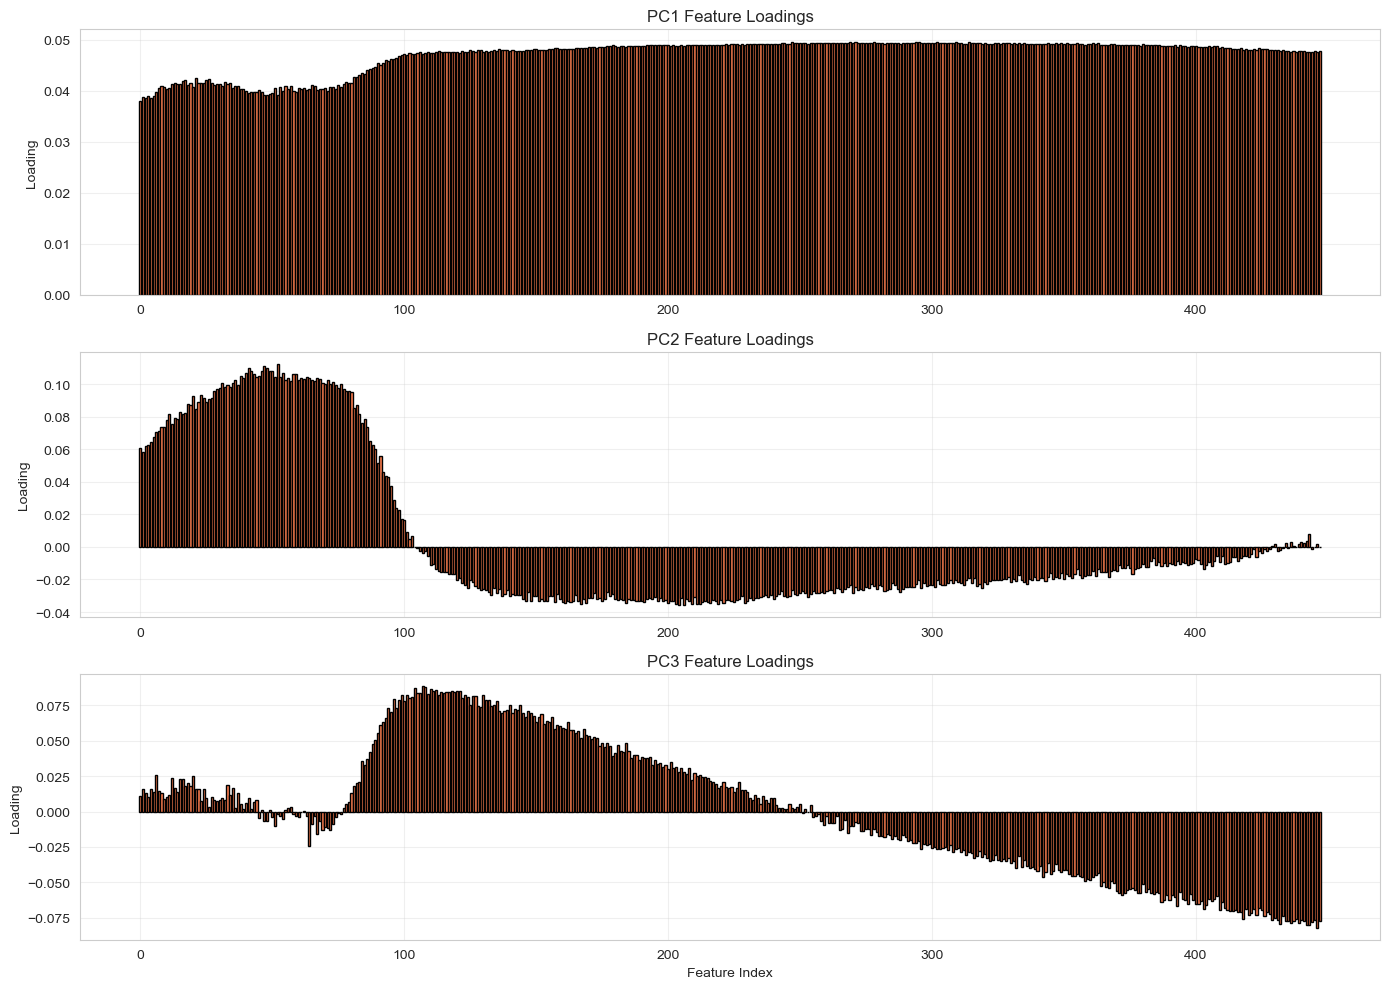

In [10]:
# Heatmap of feature contributions
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    axes[i].bar(range(len(components_df)), components_df[pc], color='coral', edgecolor='black')
    axes[i].set_ylabel('Loading')
    axes[i].set_title(f'{pc} Feature Loadings')
    axes[i].grid(alpha=0.3)
    if i == 2:
        axes[i].set_xlabel('Feature Index')

plt.tight_layout()
plt.savefig('../outputs/pca_feature_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. t-SNE Dimensionality Reduction

In [11]:
# Apply t-SNE on first 50 PCA components for efficiency
pca_50 = PCA(n_components=50)
X_train_pca50 = pca_50.fit_transform(X_train)

print("Applying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_train_tsne = tsne.fit_transform(X_train_pca50)

print(f"t-SNE shape: {X_train_tsne.shape}")

Applying t-SNE (this may take a minute)...
t-SNE shape: (400, 2)


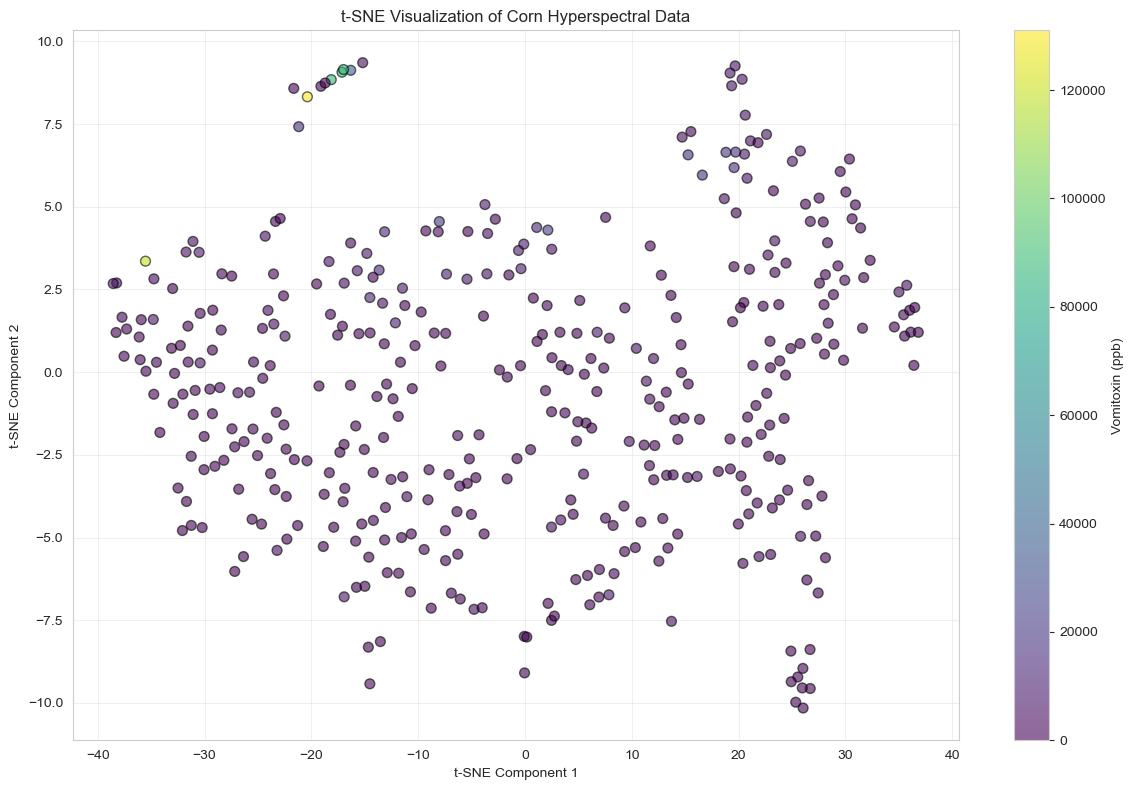

In [12]:
# t-SNE visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1],
                     c=y_train, cmap='viridis', alpha=0.6, edgecolors='black', s=50)
plt.colorbar(scatter, label='Vomitoxin (ppb)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Corn Hyperspectral Data')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Compare PCA vs t-SNE

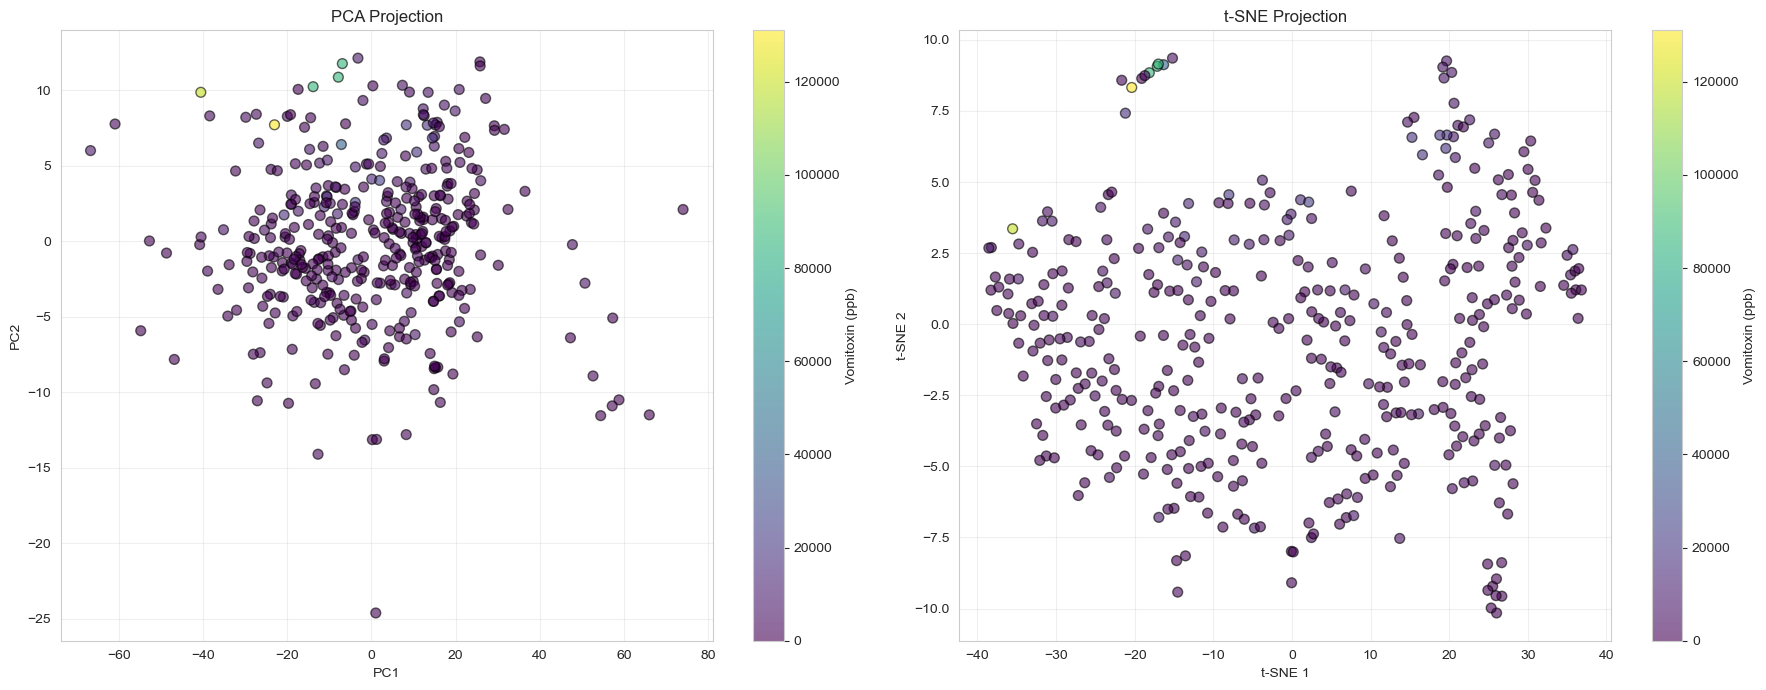

In [13]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA
scatter1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                          c=y_train, cmap='viridis', alpha=0.6, edgecolors='black', s=50)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA Projection')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Vomitoxin (ppb)')

# t-SNE
scatter2 = axes[1].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1],
                          c=y_train, cmap='viridis', alpha=0.6, edgecolors='black', s=50)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE Projection')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Vomitoxin (ppb)')

plt.tight_layout()
plt.savefig('../outputs/pca_vs_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Save PCA-Reduced Datasets

In [14]:
# Convert to DataFrame and save
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_pca_df.to_csv('../data/X_train_pca.csv', index=False)
X_test_pca_df.to_csv('../data/X_test_pca.csv', index=False)

print("✓ PCA-reduced datasets saved successfully!")
print("\nSaved files:")
print(f"  - X_train_pca.csv ({X_train_pca.shape[1]} components)")
print(f"  - X_test_pca.csv ({X_test_pca.shape[1]} components)")

✓ PCA-reduced datasets saved successfully!

Saved files:
  - X_train_pca.csv (3 components)
  - X_test_pca.csv (3 components)


## 11. Interpretation Summary

In [15]:
print("="*60)
print("DIMENSIONALITY REDUCTION INSIGHTS")
print("="*60)
print(f"\n✓ Original features: {X_train.shape[1]}")
print(f"✓ Reduced to: {X_train_pca.shape[1]} components")
print(f"✓ Variance retained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"✓ Dimensionality reduction: {(1 - X_train_pca.shape[1]/X_train.shape[1])*100:.1f}%")
print(f"\n✓ First 3 PCs explain: {pca.explained_variance_ratio_[:3].sum():.2%} variance")
print(f"✓ First 10 PCs explain: {pca.explained_variance_ratio_[:10].sum():.2%} variance")
print("\n✓ PCA: Preserves global structure, linear transformation")
print("✓ t-SNE: Reveals local clusters, non-linear transformation")
print("\n" + "="*60)
print("Ready for Notebook 3: ANN PyTorch Model")
print("="*60)

DIMENSIONALITY REDUCTION INSIGHTS

✓ Original features: 448
✓ Reduced to: 3 components
✓ Variance retained: 95.08%
✓ Dimensionality reduction: 99.3%

✓ First 3 PCs explain: 95.08% variance
✓ First 10 PCs explain: 95.08% variance

✓ PCA: Preserves global structure, linear transformation
✓ t-SNE: Reveals local clusters, non-linear transformation

Ready for Notebook 3: ANN PyTorch Model
